## Data Analysis of Customer Segmentation Dataset (EDA)

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [3]:
raw_data= pd.read_csv('../data/Train.csv')
raw_data.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [4]:
print(raw_data.shape)
print(raw_data.info())
print(raw_data.describe())
print(raw_data.isnull().sum())


(8068, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB
None
                  ID          Age  Work_Experience  Family_Size
count    8068.000000  8068.000000      7239.000000  7733.000000
mean   463479.214551    43.466906         2.641663     2.850123
std      2595.381232   

In [5]:
print(raw_data.isna().sum())

ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64


In [6]:
raw_data.head(-10)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
8053,465667,Male,No,23,No,Healthcare,1.0,Low,3.0,Cat_2,D
8054,463437,Male,Yes,49,Yes,Artist,1.0,Average,3.0,Cat_6,B
8055,461291,Male,No,18,No,Healthcare,0.0,Low,2.0,Cat_6,D
8056,459889,Male,Yes,63,Yes,Homemaker,8.0,Average,3.0,Cat_6,B


In [7]:
# Replacing NA values appropriately
copy_data=raw_data.__deepcopy__()

copy_data['Ever_Married'].fillna('No', inplace=True)
copy_data['Graduated'].fillna('No', inplace=True)
copy_data['Profession'].fillna('Other', inplace=True)
copy_data['Work_Experience'].fillna(0, inplace=True)
copy_data['Family_Size'].fillna(0, inplace=True)


C:\Users\caaka\AppData\Local\Temp\ipykernel_20832\341064699.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  copy_data['Ever_Married'].fillna('No', inplace=True)
C:\Users\caaka\AppData\Local\Temp\ipykernel_20832\341064699.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [8]:
copy_data.isna().sum()

ID                  0
Gender              0
Ever_Married        0
Age                 0
Graduated           0
Profession          0
Work_Experience     0
Spending_Score      0
Family_Size         0
Var_1              76
Segmentation        0
dtype: int64

In [9]:
# Label Encoding
le = LabelEncoder()
copy_data['Gender'] = le.fit_transform(copy_data['Gender'].map({'Male': 1, 'Female' : 0}))
copy_data['Ever_Married'] = le.fit_transform(copy_data['Ever_Married'].map({'Yes': 1, 'No' : 0}))
copy_data['Graduated'] = le.fit_transform(copy_data['Graduated'].map({'Yes': 1, 'No' : 0}))
copy_data['Profession'] = le.fit_transform(copy_data['Profession'].map({'Healthcare': 0, 'Entertainment' : 1, 'Other' : 2, 'Academic' : 3, 'Artist' : 4, 'Sports' : 5}))
copy_data['Spending_Score'] = le.fit_transform(copy_data['Spending_Score'].map({'Low': 0, 'Medium' : 1, 'High' : 2}))
copy_data['Segmentation'] = le.fit_transform(copy_data['Segmentation'].map({'A': 0, 'B' : 1, 'C' : 2, 'D' : 3}))
copy_data['Var_1'] = le.fit_transform(copy_data['Var_1'].map({'Cat_1': 0, 'Cat_2' : 1, 'Cat_3' : 2, 'Cat_4' : 3, 'Cat_5' : 4, 'Cat_6' : 5, 'Cat_7' : 6, 'Cat_8' : 7, 'Cat_9' : 8}))

In [10]:
copy_data.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,1,0,22,0,0,1.0,0,4.0,3,3
1,462643,0,1,38,1,4,0.0,2,3.0,3,0
2,466315,0,1,67,1,4,1.0,0,1.0,5,1
3,461735,1,1,67,1,4,0.0,1,2.0,5,1
4,462669,0,1,40,1,1,0.0,1,6.0,5,0


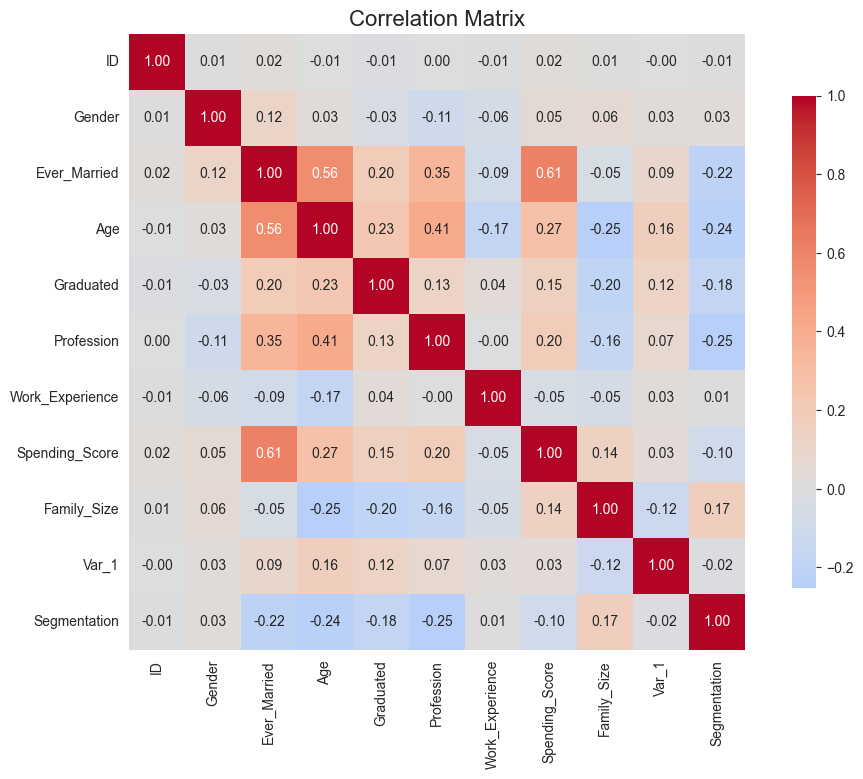

In [12]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.heatmap(copy_data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix', fontsize=16)
plt.savefig('../Outputs/plots/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
# Important Features
features=['Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size','Spending_Score']

<Figure size 1200x800 with 0 Axes>

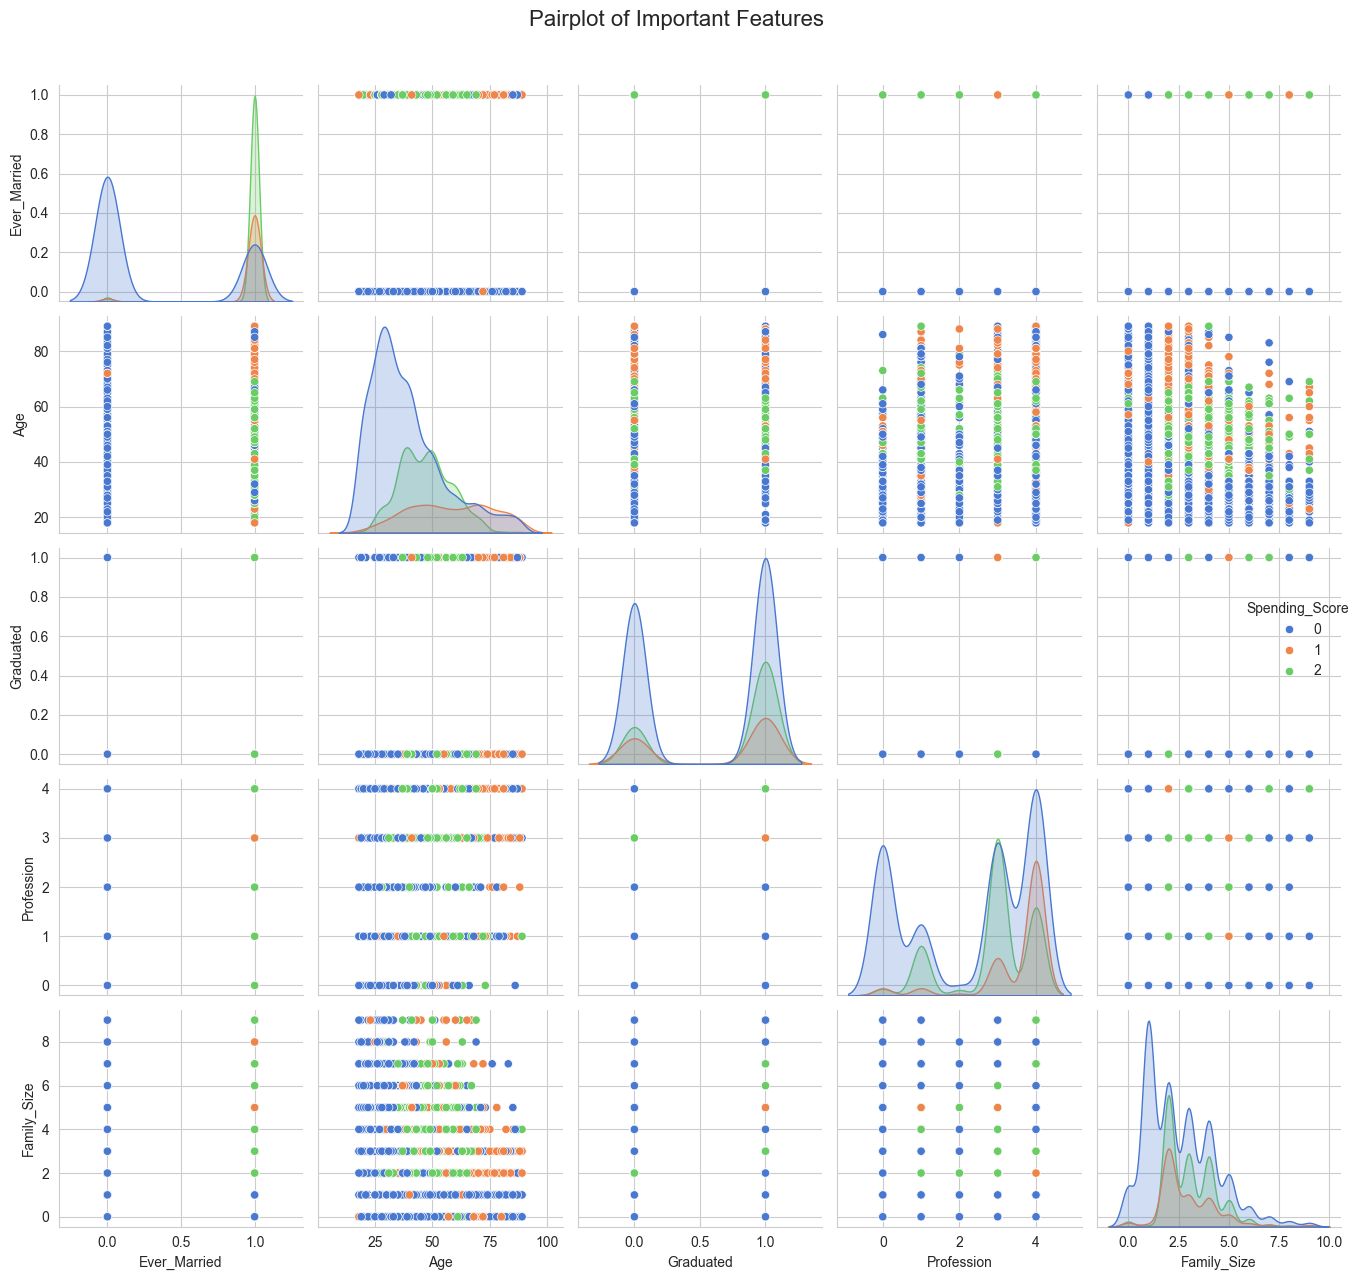

In [14]:
# Data Visualization
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.pairplot(copy_data[features], hue='Spending_Score', palette='muted')
plt.suptitle('Pairplot of Important Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('../Outputs/plots/pairplot_important_features.png', dpi=300, bbox_inches='tight')
plt.show()


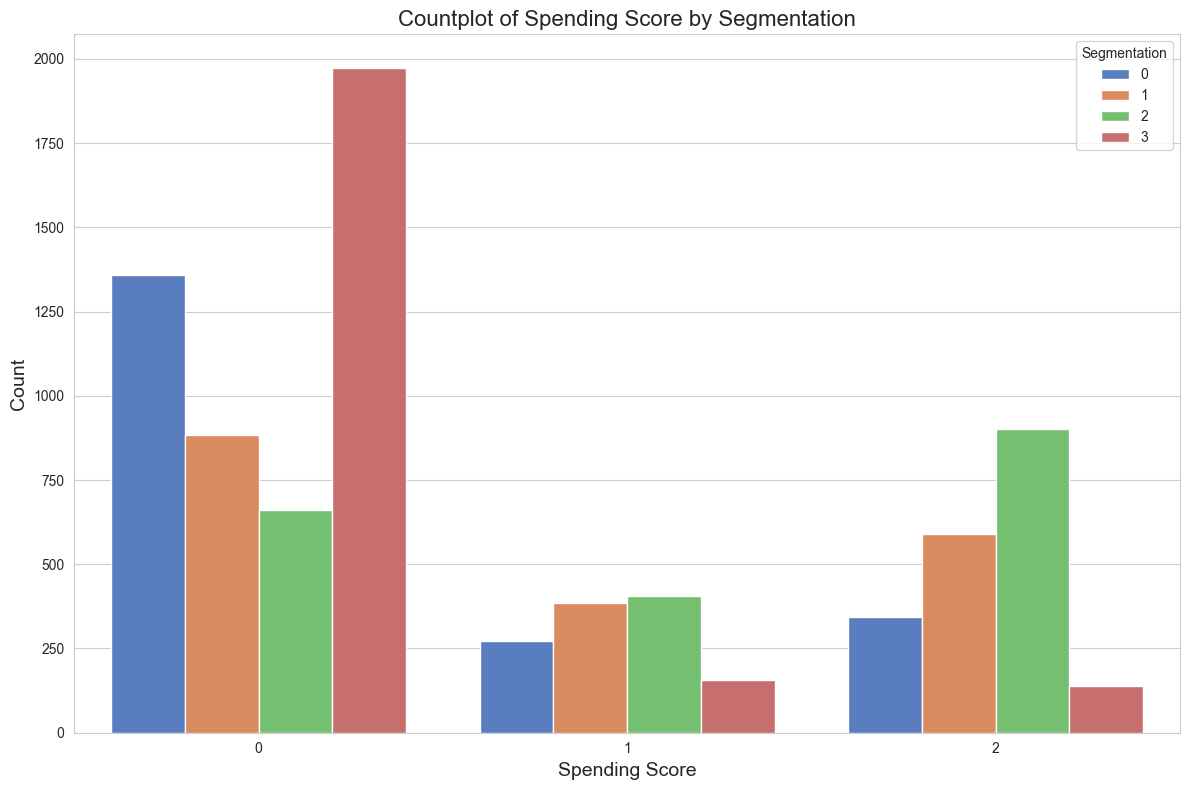

In [15]:
# Countplot

plt.figure(figsize=(12, 8))
sns.countplot(data=copy_data, x='Spending_Score', hue='Segmentation', palette='muted')
plt.title('Countplot of Spending Score by Segmentation', fontsize=16)
plt.xlabel('Spending Score', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.savefig('../Outputs/plots/countplot_spending_score.png', dpi=300, bbox_inches='tight')
plt.legend(title='Segmentation', loc='upper right')
plt.show()

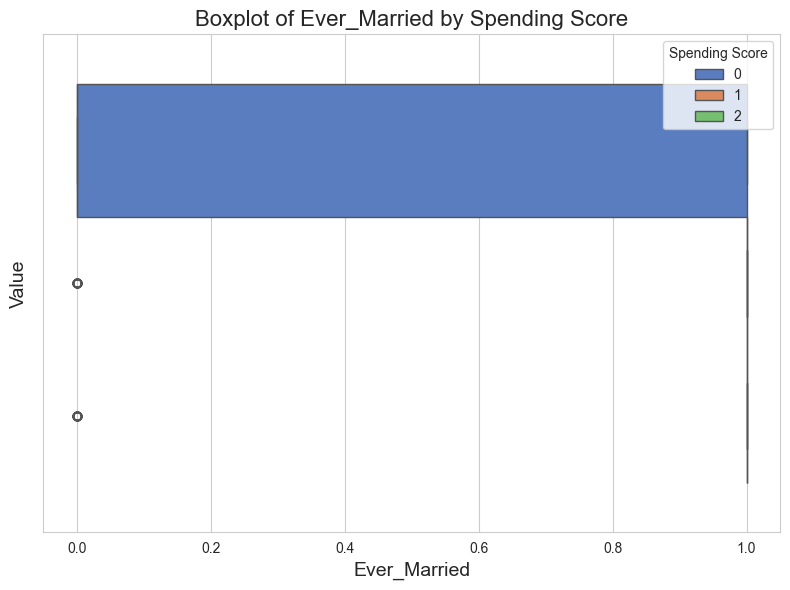

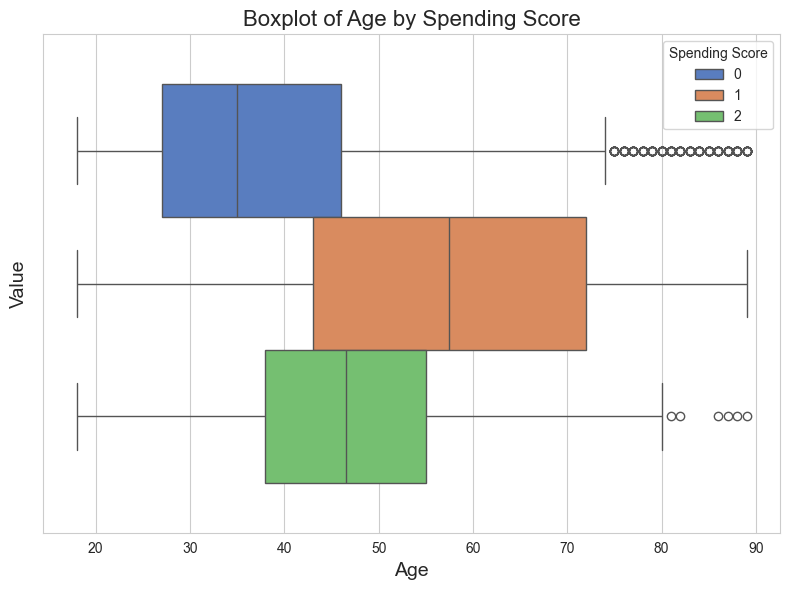

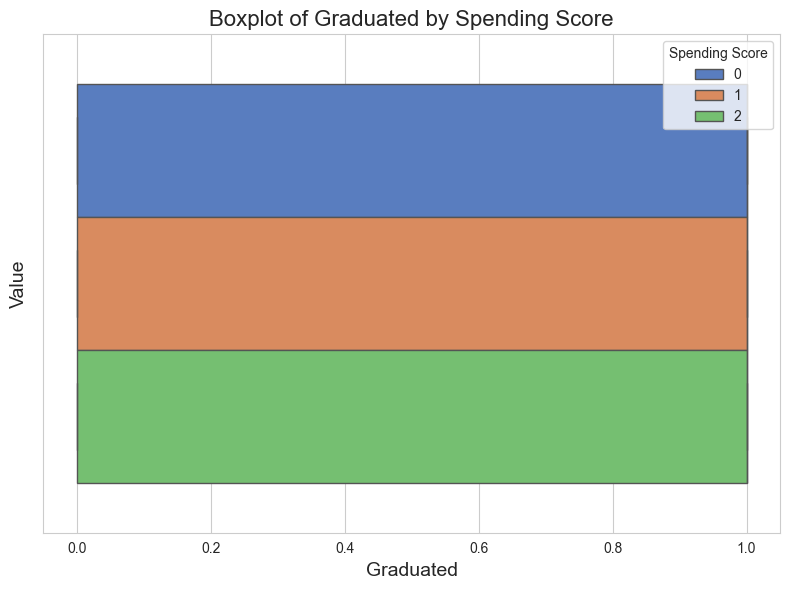

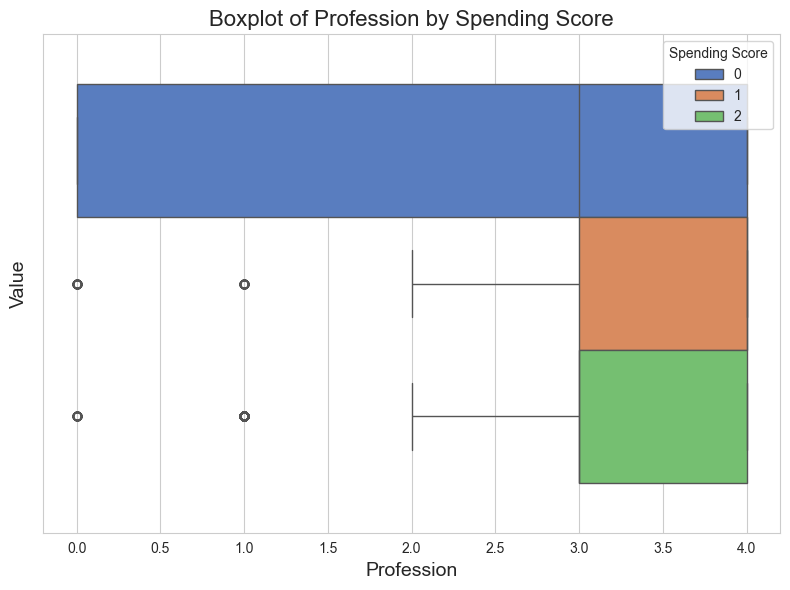

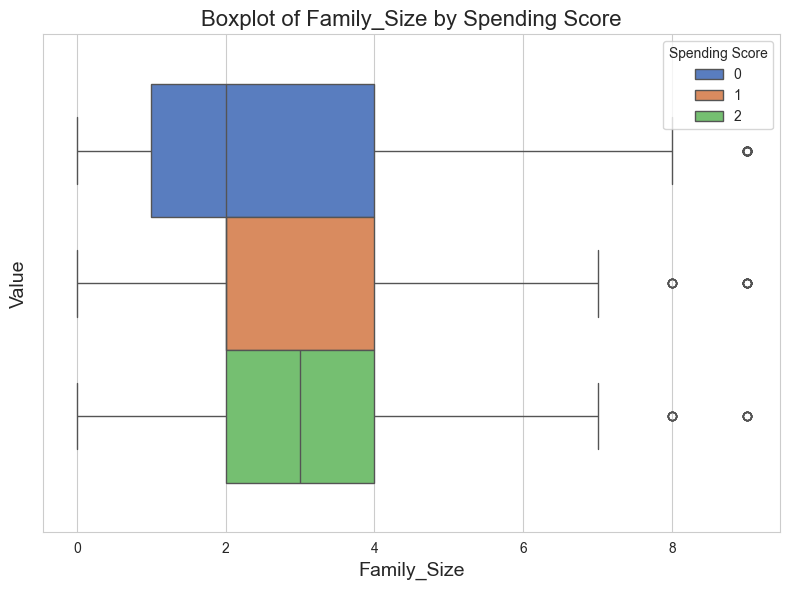

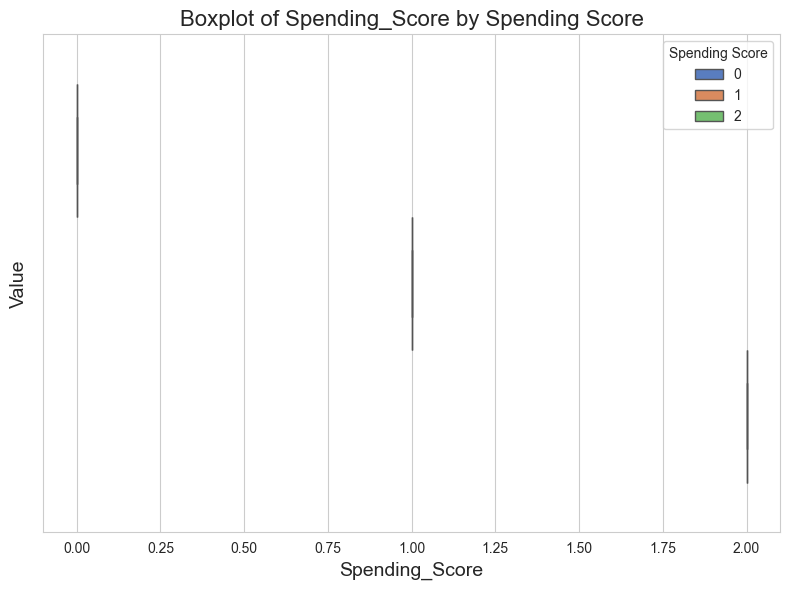

In [19]:
# Boxplot

for feature in features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=copy_data, x=feature, hue='Spending_Score', palette='muted')
    plt.title(f'Boxplot of {feature} by Spending Score', fontsize=16)
    plt.xlabel(feature, fontsize=14)
    plt.ylabel('Value', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'../Outputs/plots/boxplot_{feature}.png', dpi=300, bbox_inches='tight')
    plt.legend(title='Spending Score', loc='upper right')
    plt.show()

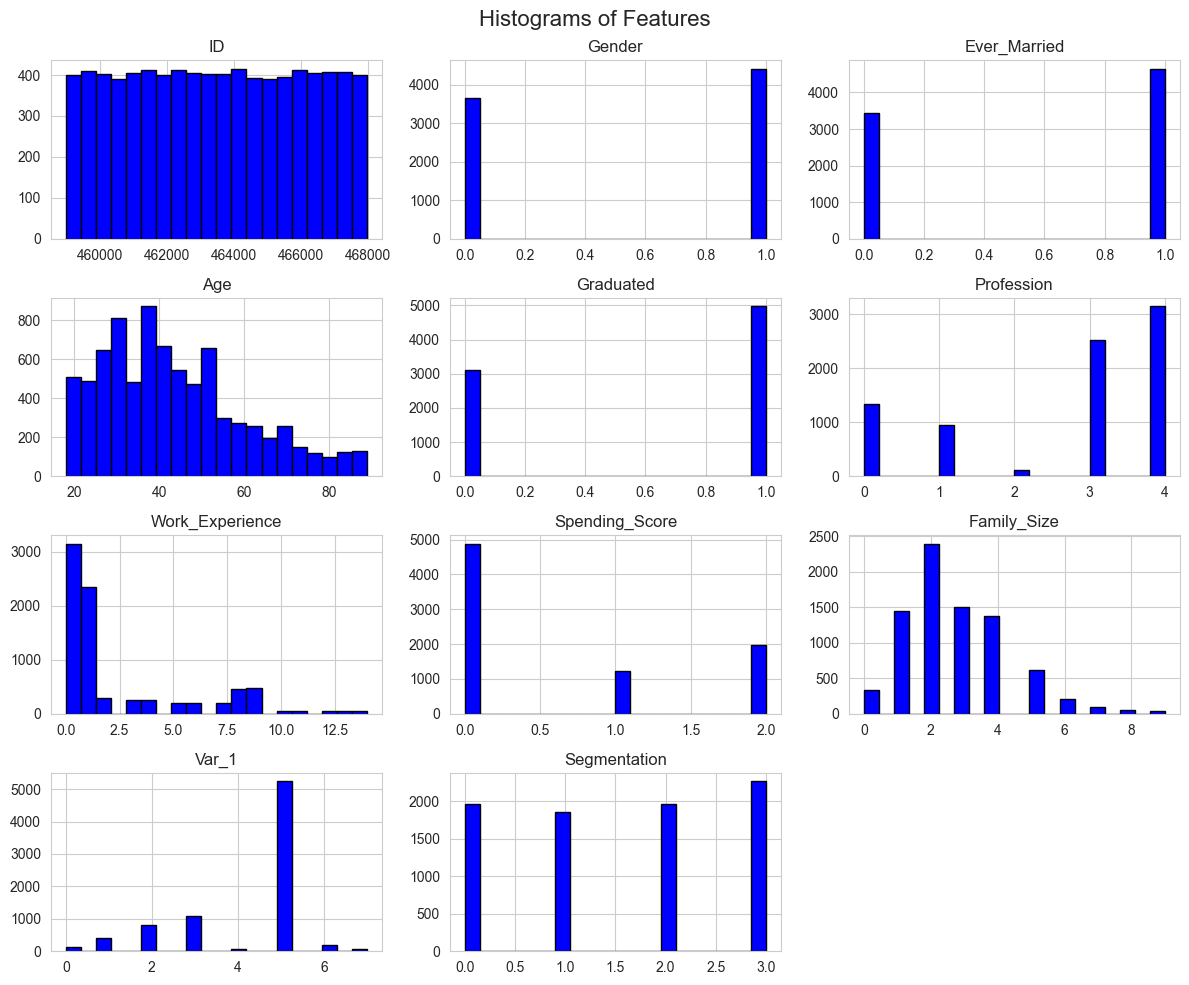

In [17]:
# Histograms

sns.set_style('whitegrid')
copy_data.hist(figsize=(12, 10), bins=20, color='blue', edgecolor='black')
plt.suptitle('Histograms of Features', fontsize=16)
plt.tight_layout()
plt.savefig('../Outputs/plots/histograms_features.png', dpi=300, bbox_inches='tight')
plt.show()

### Inferences:
- The dataset contains 8068 rows and 11 columns.
- The Spending score is most affected by the following features:
    - Ever_Married
    - Age
    - Graduated
    - Profession
    - Family_Size
- The dataset has highest frequency of spending score (highest spending score) from people who have a low salary in Segment D.
- The dataset has least frequency of spending score (least spending score) from people who have a high salary in Segment D.
- Further analysis can be done using classification algorithms to predict the spending score based on the features.
- The dataset can be used to identify customer segments for targeted marketing strategies.